# IMD - Reader

The India Meteorological Department (IMD) publishes radar data as NetCDF4 files
with an IRIS-inspired variable layout. Each file holds **one sweep**; a
complete volume is assembled from multiple files: typically 2-3 files for
long-range PPI and 9-10 files for short-range, high-resolution PPI.

In [1]:
import xarray as xr

import xradar as xd

## Download

IMD sample files are hosted in the
[pyscancf_examples](https://github.com/syedhamidali/pyscancf_examples)
repository. We fetch them with `pooch`.

In [2]:
import pooch

base = "https://github.com/syedhamidali/pyscancf_examples/raw/main/data/goa_c"
filename_sweep_0 = pooch.retrieve(
    url=f"{base}/GOA210515003646-IMD-C.nc",
    known_hash=None,
    fname="GOA210515003646-IMD-C.nc",
)
filename_sweep_1 = pooch.retrieve(
    url=f"{base}/GOA210515003646-IMD-C.nc.1",
    known_hash=None,
    fname="GOA210515003646-IMD-C.nc.1",
)
volume_files = [filename_sweep_0, filename_sweep_1]

## `xr.open_dataset` — a single sweep

The xarray `imd` backend reads a single IMD NetCDF file and returns a
CfRadial2-compatible sweep Dataset. Moments are renamed (`T`→`DBTH`,
`Z`→`DBZH`, `V`→`VRADH`, `W`→`WRADH`; dual-pol sites additionally carry
`ZDR` and `HCLASS`) and canonical CfRadial2 moment attributes
(`standard_name`, `long_name`, `units`) are applied.

In [4]:
ds = xr.open_dataset(filename_sweep_0, engine="imd")
display(ds)

<xarray.Dataset> Size: 3MB
Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
Coordinates:
  * azimuth                   (azimuth) float32 1kB 0.8569 1.857 ... 358.9 359.8
    elevation                 (azimuth) float32 1kB ...
    time                      (azimuth) datetime64[ns] 3kB ...
  * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
  * frequency                 (frequency) float32 4B 2.799e+09
    latitude                  float32 4B ...
    longitude                 float32 4B ...
    altitude                  float32 4B ...
Data variables: (12/44)
    nyquist_velocity          float32 4B ...
    unambiguous_range         float32 4B ...
    calibConst                float32 4B ...
    radarConst                float32 4B ...
    radar_beam_width_h        float32 4B ...
    radar_receiver_bandwidth  float32 4B ...
    ...                        ...
    scan_rate                 (azimuth) float32 1kB ...
    n_samples                 (azimuth) int32 1kB ...
    pulse_width               (azimuth) float32 1kB ...
    sweep_fixed_angle         float64 8B ...
    sweep_number              int64 8B ...
    rays_angle_resolution     float64 8B ...
Attributes:
    Content:              This file contains one scan of remotely sensed data
    history:              Encoded into netcdf from IRIS data
    title:                IRIS data
    Conventions:          FSL netCDF
    time_coverage_start:  2021-05-15T00:36:46Z
    time_coverage_end:    2021-05-15T00:37:17Z

### Plot Range vs. Azimuth

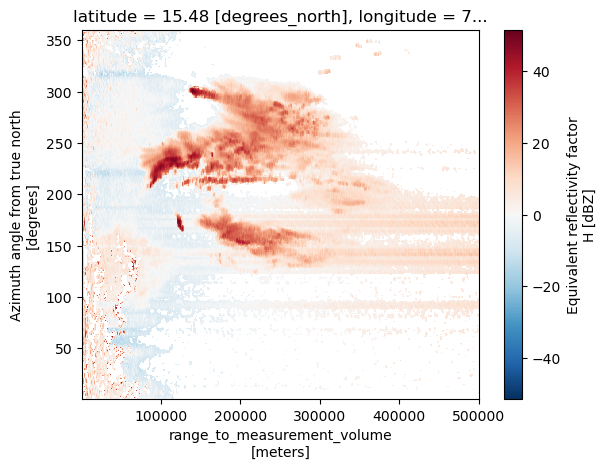

In [5]:
ds.DBZH.plot(y="azimuth")

## backend_kwargs

In [6]:
help(xd.io.IMDBackendEntrypoint)

Help on class IMDBackendEntrypoint in module xradar.io.backends.imd:

class IMDBackendEntrypoint(xarray.backends.common.BackendEntrypoint)
 |  Xarray BackendEntrypoint for India Meteorological Department (IMD) radar files.
 |
 |  IMD provides one NetCDF file per sweep. Open a single file with
 |  ``xr.open_dataset(file, engine="imd")`` to get a CfRadial2-compatible sweep
 |  :py:class:`xarray.Dataset`. To assemble a multi-sweep volume, use
 |  :func:`open_imd_datatree` with a list of files.
 |
 |  Keyword Arguments
 |  -----------------
 |  first_dim : str
 |      Can be ``time`` or ``auto`` (default). ``auto`` selects ``azimuth``
 |      (PPI) or ``elevation`` (RHI) as the first dimension.
 |  reindex_angle : bool or dict
 |      If a dict, kwargs are passed to :func:`xradar.util.reindex_angle`.
 |      Defaults to ``False``.
 |  site_as_coords : bool
 |      If True (default), promote ``latitude``/``longitude``/``altitude`` to
 |      Dataset coordinates.
 |
 |  Method resolution ord

In [7]:
ds = xr.open_dataset(filename_sweep_0, engine="imd", first_dim="time")
display(ds)

<xarray.Dataset> Size: 3MB
Dimensions:                   (time: 360, range: 500, frequency: 1)
Coordinates:
  * time                      (time) datetime64[ns] 3kB 2021-05-15T00:36:47 ....
    azimuth                   (time) float32 1kB ...
    elevation                 (time) float32 1kB ...
  * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
  * frequency                 (frequency) float32 4B 2.799e+09
    latitude                  float32 4B ...
    longitude                 float32 4B ...
    altitude                  float32 4B ...
Data variables: (12/44)
    nyquist_velocity          float32 4B ...
    unambiguous_range         float32 4B ...
    calibConst                float32 4B ...
    radarConst                float32 4B ...
    radar_beam_width_h        float32 4B ...
    radar_receiver_bandwidth  float32 4B ...
    ...                        ...
    scan_rate                 (time) float32 1kB ...
    n_samples                 (time) int32 1kB ...
    pulse_width               (time) float32 1kB ...
    sweep_fixed_angle         float64 8B ...
    sweep_number              int64 8B ...
    rays_angle_resolution     float64 8B ...
Attributes:
    Content:              This file contains one scan of remotely sensed data
    history:              Encoded into netcdf from IRIS data
    title:                IRIS data
    Conventions:          FSL netCDF
    time_coverage_start:  2021-05-15T00:36:46Z
    time_coverage_end:    2021-05-15T00:37:17Z

## `open_imd_datatree` — one volume

`open_imd_datatree` accepts **either** a single file path (→ single-sweep
DataTree) **or** a list of file paths (→ one volume). Multi-file stacking
is delegated to `xradar.util.create_volume`, which sorts sweeps by time
and supports `min_angle` / `max_angle` / `time_coverage_start` /
`time_coverage_end` / `volume_number` filtering.

In [8]:
help(xd.io.open_imd_datatree)

Help on function open_imd_datatree in module xradar.io.backends.imd:

open_imd_datatree(filename_or_obj, **kwargs)
    Open IMD radar file(s) as a :py:class:`xarray.DataTree`.

    IMD stores one sweep per NetCDF file. A volume is assembled from
    multiple files (typically 2-3 for long-range PPI or 9-10 for
    short-range, high-resolution PPI).

    - Single file path -> single-sweep DataTree.
    - List of file paths -> single volume DataTree. Multi-file stacking
      is delegated to :func:`xradar.util.create_volume`, which sorts
      sweeps by time and supports ``time_coverage_start``,
      ``time_coverage_end``, ``min_angle``, ``max_angle`` filtering.

    To split a directory of mixed-volume files into per-volume groups,
    use :func:`group_imd_files` first::

        for group in xd.io.group_imd_files("/data/imd"):
            dtree = xd.io.open_imd_datatree(group)

    Parameters
    ----------
    filename_or_obj : str, Path, or list/tuple of those
        Single IMD file

### Single sweep

In [9]:
dtree = xd.io.open_imd_datatree(filename_sweep_0, optional_groups=True)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Coordinates:
│       latitude             float32 4B ...
│       altitude             float32 4B ...
│       longitude            float32 4B ...
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2021-05-15T00:36:46Z'
│       time_coverage_end    <U20 80B '2021-05-15T00:37:17Z'
│       sweep_fixed_angle    (sweep) float64 8B 0.4999
│       sweep_group_name     (sweep) <U7 28B 'sweep_0'
│   Attributes:
│       Conventions:         CF-1.8, WMO CF-1.0, ACDD-1.3
│       wmo__cf_profile:     FM 301-XX
│       version:             2.0
│       title:               IMD radar data
│       institution:         India Meteorological Department
│       references:          
│       source:              IMD NetCDF
│       history:             
│       comment:             
│       instrument_name:     
│       platform_is_mobile:  false
├── Group: /radar_parameters
│       Dimensions:                   ()
│       Data variables:
│           radar_beam_width_h        float32 4B ...
│           radar_beam_width_v        float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
├── Group: /georeferencing_correction
├── Group: /radar_calibration
│       Dimensions:           ()
│       Data variables:
│           calI0             float32 4B ...
│           calNoise          float32 4B ...
│           calibConst        float32 4B ...
│           inphaseOffset     float32 4B ...
│           linNoise          float32 4B ...
│           logNoise          float32 4B ...
│           quadratureOffset  float32 4B ...
│           radarConst        float32 4B ...
│       Attributes:
│           Content:              This file contains one scan of remotely sensed data
│           history:              Encoded into netcdf from IRIS data
│           title:                IRIS data
│           Conventions:          FSL netCDF
│           time_coverage_start:  2021-05-15T00:36:46Z
│           time_coverage_end:    2021-05-15T00:37:17Z
└── Group: /sweep_0
        Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
        Coordinates:
          * azimuth                   (azimuth) float32 1kB 0.8569 1.857 ... 358.9 359.8
            elevation                 (azimuth) float32 1kB ...
            time                      (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:0...
          * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
          * frequency                 (frequency) float32 4B 2.799e+09
        Data variables: (12/44)
            nyquist_velocity          float32 4B ...
            unambiguous_range         float32 4B ...
            calibConst                float32 4B ...
            radarConst                float32 4B ...
            radar_beam_width_h        float32 4B ...
            radar_receiver_bandwidth  float32 4B ...
            ...                        ...
            scan_rate                 (azimuth) float32 1kB 12.0 12.0 12.0 ... 12.0 12.0
            n_samples                 (azimuth) int32 1kB 70 70 70 70 70 ... 70 70 70 70
            pulse_width               (azimuth) float32 1kB 2e-06 2e-06 ... 2e-06 2e-06
            sweep_fixed_angle         float64 8B 0.4999
            sweep_number              int64 8B 0
            rays_angle_resolution     float64 8B 1.0

### Volume from multiple files

In [11]:
dtree = xd.io.open_imd_datatree(volume_files, optional_groups=True)
display(dtree)

<xarray.DataTree 'root'>
Group: /
│   Dimensions:              (sweep: 2)
│   Coordinates:
│       latitude             float32 4B ...
│       altitude             float32 4B ...
│       longitude            float32 4B ...
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2021-05-15T00:36:47Z'
│       time_coverage_end    <U20 80B '2021-05-15T00:37:47Z'
│       sweep_group_name     (sweep) <U7 56B 'sweep_0' 'sweep_1'
│       sweep_fixed_angle    (sweep) float64 16B 0.4999 0.9998
│   Attributes:
│       Conventions:         CF-1.8, WMO CF-1.0, ACDD-1.3
│       wmo__cf_profile:     FM 301-XX
│       version:             2.0
│       title:               IMD radar data
│       institution:         India Meteorological Department
│       references:          
│       source:              IMD NetCDF
│       history:             
│       comment:             
│       instrument_name:     
│       platform_is_mobile:  false
│       volume_number:       0
├── Group: /sweep_0
│       Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
│       Coordinates:
│         * azimuth                   (azimuth) float32 1kB 0.8569 1.857 ... 358.9 359.8
│           elevation                 (azimuth) float32 1kB ...
│           time                      (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:0...
│         * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
│         * frequency                 (frequency) float32 4B 2.799e+09
│       Data variables: (12/44)
│           nyquist_velocity          float32 4B ...
│           unambiguous_range         float32 4B ...
│           calibConst                float32 4B ...
│           radarConst                float32 4B ...
│           radar_beam_width_h        float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
│           ...                        ...
│           scan_rate                 (azimuth) float32 1kB 12.0 12.0 12.0 ... 12.0 12.0
│           n_samples                 (azimuth) int32 1kB 70 70 70 70 70 ... 70 70 70 70
│           pulse_width               (azimuth) float32 1kB 2e-06 2e-06 ... 2e-06 2e-06
│           sweep_fixed_angle         float64 8B 0.4999
│           sweep_number              int64 8B 0
│           rays_angle_resolution     float64 8B 1.0
└── Group: /sweep_1
        Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
        Coordinates:
          * azimuth                   (azimuth) float32 1kB 0.8569 1.84 ... 358.8 359.9
            elevation                 (azimuth) float32 1kB ...
            time                      (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:3...
          * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
          * frequency                 (frequency) float32 4B 2.799e+09
        Data variables: (12/44)
            nyquist_velocity          float32 4B ...
            unambiguous_range         float32 4B ...
            calibConst                float32 4B ...
            radarConst                float32 4B ...
            radar_beam_width_h        float32 4B ...
            radar_receiver_bandwidth  float32 4B ...
            ...                        ...
            scan_rate                 (azimuth) float32 1kB 12.0 12.0 12.0 ... 12.0 12.0
            n_samples                 (azimuth) int32 1kB 70 70 70 70 70 ... 70 70 70 70
            pulse_width               (azimuth) float32 1kB 2e-06 2e-06 ... 2e-06 2e-06
            sweep_fixed_angle         float64 8B 0.9998
            sweep_number              int64 8B 1
            rays_angle_resolution     float64 8B 1.0

### Plot a georeferenced PPI

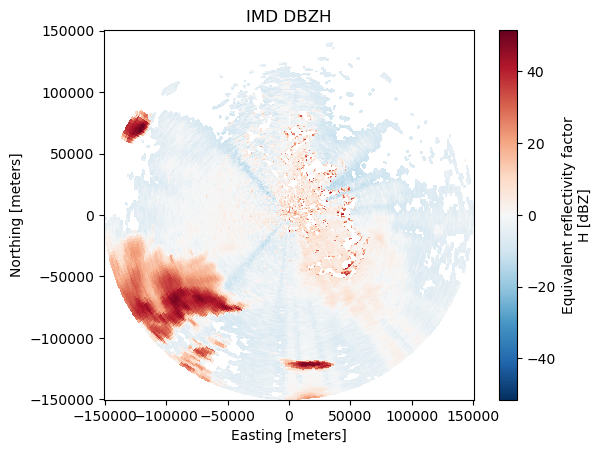

In [12]:
import matplotlib.pyplot as plt

sweep = dtree["sweep_0"].to_dataset(inherit="all_coords")
sweep = sweep.sel(range=slice(0, 150000))
sweep = xd.georeference.get_x_y_z(sweep)
sweep.DBZH.plot(x="x", y="y")
plt.title("IMD DBZH")
plt.gca().set_aspect("equal")

### Filter by elevation angle

In [13]:
dtree = xd.io.open_imd_datatree(volume_files, max_angle=5.0)
display(dtree)

<xarray.DataTree 'root'>
Group: /
│   Dimensions:              (sweep: 2)
│   Coordinates:
│       latitude             float32 4B ...
│       altitude             float32 4B ...
│       longitude            float32 4B ...
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2021-05-15T00:36:47Z'
│       time_coverage_end    <U20 80B '2021-05-15T00:37:47Z'
│       sweep_group_name     (sweep) <U7 56B 'sweep_0' 'sweep_1'
│       sweep_fixed_angle    (sweep) float64 16B 0.4999 0.9998
│   Attributes:
│       Conventions:         CF-1.8, WMO CF-1.0, ACDD-1.3
│       wmo__cf_profile:     FM 301-XX
│       version:             2.0
│       title:               IMD radar data
│       institution:         India Meteorological Department
│       references:          
│       source:              IMD NetCDF
│       history:             
│       comment:             
│       instrument_name:     
│       platform_is_mobile:  false
│       volume_number:       0
├── Group: /sweep_0
│       Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
│       Coordinates:
│         * azimuth                   (azimuth) float32 1kB 0.8569 1.857 ... 358.9 359.8
│           elevation                 (azimuth) float32 1kB ...
│           time                      (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:0...
│         * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
│         * frequency                 (frequency) float32 4B 2.799e+09
│       Data variables: (12/44)
│           nyquist_velocity          float32 4B ...
│           unambiguous_range         float32 4B ...
│           calibConst                float32 4B ...
│           radarConst                float32 4B ...
│           radar_beam_width_h        float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
│           ...                        ...
│           scan_rate                 (azimuth) float32 1kB 12.0 12.0 12.0 ... 12.0 12.0
│           n_samples                 (azimuth) int32 1kB 70 70 70 70 70 ... 70 70 70 70
│           pulse_width               (azimuth) float32 1kB 2e-06 2e-06 ... 2e-06 2e-06
│           sweep_fixed_angle         float64 8B 0.4999
│           sweep_number              int64 8B 0
│           rays_angle_resolution     float64 8B 1.0
└── Group: /sweep_1
        Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
        Coordinates:
          * azimuth                   (azimuth) float32 1kB 0.8569 1.84 ... 358.8 359.9
            elevation                 (azimuth) float32 1kB ...
            time                      (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:3...
          * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
          * frequency                 (frequency) float32 4B 2.799e+09
        Data variables: (12/44)
            nyquist_velocity          float32 4B ...
            unambiguous_range         float32 4B ...
            calibConst                float32 4B ...
            radarConst                float32 4B ...
            radar_beam_width_h        float32 4B ...
            radar_receiver_bandwidth  float32 4B ...
            ...                        ...
            scan_rate                 (azimuth) float32 1kB 12.0 12.0 12.0 ... 12.0 12.0
            n_samples                 (azimuth) int32 1kB 70 70 70 70 70 ... 70 70 70 70
            pulse_width               (azimuth) float32 1kB 2e-06 2e-06 ... 2e-06 2e-06
            sweep_fixed_angle         float64 8B 0.9998
            sweep_number              int64 8B 1
            rays_angle_resolution     float64 8B 1.0

## `group_imd_files` — split a mixed directory

A single directory usually holds many volumes back-to-back. Use
`group_imd_files` to split a directory (or glob, or list) into per-volume
file lists by filename stem:

In [14]:
help(xd.io.group_imd_files)

Help on function group_imd_files in module xradar.io.backends.imd:

group_imd_files(paths)
    Group IMD sweep files into volumes by filename stem.

    IMD distributes one sweep per file. Files of a single volume share a
    common stem ending in ``.nc``; additional sweeps in the same volume
    get numeric suffixes::

        GOA210515003646-IMD-C.nc        <- sweep 0
        GOA210515003646-IMD-C.nc.1      <- sweep 1
        ...
        GOA210515003646-IMD-C.nc.9      <- sweep 9

    A new volume changes the timestamp component of the stem.

    Parameters
    ----------
    paths : str, Path, or iterable of those
        * A directory path -- all IMD files inside are grouped.
        * A glob pattern string -- files matching the glob are grouped.
        * An iterable of file paths -- grouped as-is.

    Returns
    -------
    list[list[str]]
        One list of absolute paths per detected volume, inner lists in
        sweep order (``.nc``, ``.nc.1``, ...).

    Examples
    ----

In [15]:
# With only the 2 downloaded files there's 1 volume group.
xd.io.group_imd_files(volume_files)

[['/Users/syed44/Library/Caches/pooch/GOA210515003646-IMD-C.nc',
  '/Users/syed44/Library/Caches/pooch/GOA210515003646-IMD-C.nc.1']]

Typical loop pattern over a directory of many volumes:

```python
for files in xd.io.group_imd_files("/data/imd"):
    dtree = xd.io.open_imd_datatree(files)
    # ... process this volume ...
```

## `open_imd_volumes` — all volumes in one DataTree

`open_imd_volumes` opens every volume in a directory at once and nests
them under zero-padded `vcp_NN` child nodes (VCP = *volume coverage
pattern*). The padding width is chosen so the child names sort lexically:

```
/
├── vcp_00/
│   ├── (root: sweep_group_name, sweep_fixed_angle, ...)
│   ├── sweep_0
│   ├── sweep_1
│   └── ...
├── vcp_01/
└── ...
```

All `open_imd_datatree` kwargs (`first_dim`, `reindex_angle`,
`optional_groups`, `min_angle`/`max_angle`, ...) are forwarded and applied
per volume.

In [16]:
help(xd.io.open_imd_volumes)

Help on function open_imd_volumes in module xradar.io.backends.imd:

open_imd_volumes(paths, **kwargs)
    Open a directory of IMD files as a multi-volume :py:class:`xarray.DataTree`.

    Groups files by filename stem via :func:`group_imd_files`, opens each
    group as a CfRadial2 volume via :func:`open_imd_datatree`, and nests
    them under zero-padded ``vcp_NN`` child nodes of a parent root.
    ``vcp`` stands for *volume coverage pattern*. Padding width is chosen
    so the child names sort lexically (e.g. 121 volumes -> ``vcp_000`` ..
    ``vcp_120``).

    Parameters
    ----------
    paths : str, Path, or iterable of those
        Same as :func:`group_imd_files`: directory, glob, or list.

    Keyword Arguments
    -----------------
    All kwargs are forwarded to :func:`open_imd_datatree` (applied per
    volume). Typical: ``first_dim``, ``reindex_angle``, ``site_as_coords``,
    ``optional_groups``, ``min_angle``, ``max_angle``.

    Returns
    -------
    dtree : xarray.D

In [17]:
# On our 2-file sample this yields a single vcp_00 with 2 sweeps.
tree = xd.io.open_imd_volumes(volume_files)
display(tree)

<xarray.DataTree>
Group: /
│   Attributes:
│       Conventions:  Cf/Radial
│       institution:  India Meteorological Department
│       source:       IMD NetCDF
│       title:        IMD multi-volume dataset (1 volumes)
└── Group: /vcp_00
    │   Dimensions:              (sweep: 2)
    │   Coordinates:
    │       latitude             float32 4B ...
    │       altitude             float32 4B ...
    │       longitude            float32 4B ...
    │   Dimensions without coordinates: sweep
    │   Data variables:
    │       volume_number        int64 8B 0
    │       platform_type        <U5 20B 'fixed'
    │       instrument_type      <U5 20B 'radar'
    │       time_coverage_start  <U20 80B '2021-05-15T00:36:47Z'
    │       time_coverage_end    <U20 80B '2021-05-15T00:37:47Z'
    │       sweep_group_name     (sweep) <U7 56B 'sweep_0' 'sweep_1'
    │       sweep_fixed_angle    (sweep) float64 16B 0.4999 0.9998
    │   Attributes:
    │       Conventions:         CF-1.8, WMO CF-1.0, ACDD-1.3
    │       wmo__cf_profile:     FM 301-XX
    │       version:             2.0
    │       title:               IMD radar data
    │       institution:         India Meteorological Department
    │       references:          
    │       source:              IMD NetCDF
    │       history:             
    │       comment:             
    │       instrument_name:     
    │       platform_is_mobile:  false
    │       volume_number:       0
    ├── Group: /vcp_00/sweep_0
    │       Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
    │       Coordinates:
    │         * azimuth                   (azimuth) float32 1kB 0.8569 1.857 ... 358.9 359.8
    │           elevation                 (azimuth) float32 1kB ...
    │           time                      (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:0...
    │         * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
    │         * frequency                 (frequency) float32 4B 2.799e+09
    │       Data variables: (12/44)
    │           nyquist_velocity          float32 4B ...
    │           unambiguous_range         float32 4B ...
    │           calibConst                float32 4B ...
    │           radarConst                float32 4B ...
    │           radar_beam_width_h        float32 4B ...
    │           radar_receiver_bandwidth  float32 4B ...
    │           ...                        ...
    │           scan_rate                 (azimuth) float32 1kB 12.0 12.0 12.0 ... 12.0 12.0
    │           n_samples                 (azimuth) int32 1kB 70 70 70 70 70 ... 70 70 70 70
    │           pulse_width               (azimuth) float32 1kB 2e-06 2e-06 ... 2e-06 2e-06
    │           sweep_fixed_angle         float64 8B 0.4999
    │           sweep_number              int64 8B 0
    │           rays_angle_resolution     float64 8B 1.0
    └── Group: /vcp_00/sweep_1
            Dimensions:                   (azimuth: 360, range: 500, frequency: 1)
            Coordinates:
              * azimuth                   (azimuth) float32 1kB 0.8569 1.84 ... 358.8 359.9
                elevation                 (azimuth) float32 1kB ...
                time                      (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:3...
              * range                     (range) float64 4kB 1e+03 2e+03 ... 4.99e+05 5e+05
              * frequency                 (frequency) float32 4B 2.799e+09
            Data variables: (12/44)
                nyquist_velocity          float32 4B ...
                unambiguous_range         float32 4B ...
                calibConst                float32 4B ...
                radarConst                float32 4B ...
                radar_beam_width_h        float32 4B ...
                radar_receiver_bandwidth  float32 4B ...
                ...                        ...
                scan_rate                 (azimuth) float32 1kB 12.0 12.0 12.0 ... 12.0 12.0
                n_samples       

In [19]:
# Dig straight into any sweep with a path-style key:
tree["vcp_00/sweep_0"].ds["DBZH"]

<xarray.DataArray 'DBZH' (azimuth: 360, range: 500)> Size: 720kB
[180000 values with dtype=float32]
Coordinates:
  * azimuth    (azimuth) float32 1kB 0.8569 1.857 2.873 ... 357.9 358.9 359.8
    elevation  (azimuth) float32 1kB ...
    time       (azimuth) datetime64[ns] 3kB 2021-05-15T00:37:00 ... 2021-05-1...
  * range      (range) float64 4kB 1e+03 2e+03 3e+03 ... 4.98e+05 4.99e+05 5e+05
Attributes:
    units:          dBZ
    long_name:      Equivalent reflectivity factor H
    polarization:   Horizontal
    standard_name:  radar_equivalent_reflectivity_factor_h